Section 1：Import

In [ ]:
#匯入套件
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#重新載入 preprocessing pipeline
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    NormalizeIntensityd,
)

Section 2：Dataset Path

In [ ]:
#設定資料路徑
data_dir = "../data/raw/Task01_BrainTumour"

images_dir = f"{data_dir}/imagesTr"
labels_dir = f"{data_dir}/labelsTr"

Section 3：Load MRI + Label

In [ ]:
#建立第一筆資料
image_path = f"{images_dir}/BRATS_001.nii.gz"
label_path = f"{labels_dir}/BRATS_001.nii.gz"


data = {
    "image": image_path,
    "label": label_path
}

data

{'image': '../data/raw/Task01_BrainTumour/imagesTr/BRATS_001.nii.gz',
 'label': '../data/raw/Task01_BrainTumour/labelsTr/BRATS_001.nii.gz'}

Section 4：Preprocessing

In [ ]:
#建立 preprocessing pipeline
transform = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),

        Orientationd(
            keys=["image", "label"],
            axcodes="RAS"
        ),

        Spacingd(
            keys=["image", "label"],
            pixdim=(1.0,1.0,1.0),
            mode=("bilinear","nearest")
        ),

        NormalizeIntensityd(
            keys="image",
            nonzero=True,
            channel_wise=True,
        ),
    ]
)

/opt/anaconda3/envs/medical-ai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [ ]:
#執行
sample = transform(data)

In [ ]:
#確認資料
image = sample["image"]
label = sample["label"]


print(image.shape)
print(label.shape)

torch.Size([4, 240, 240, 155])
torch.Size([1, 240, 240, 155])


Section 5：Extract MRI modality

In [35]:
image = sample["image"]

flair = image[3]

Section 6：Extract Label

In [36]:
label = sample["label"]

mask = label[0]

Section 7：Select slice

slice_idx = 77


slice_img = flair[:,:,slice_idx]

mask_slice = mask[:,:,slice_idx]

Section 8：Visualization

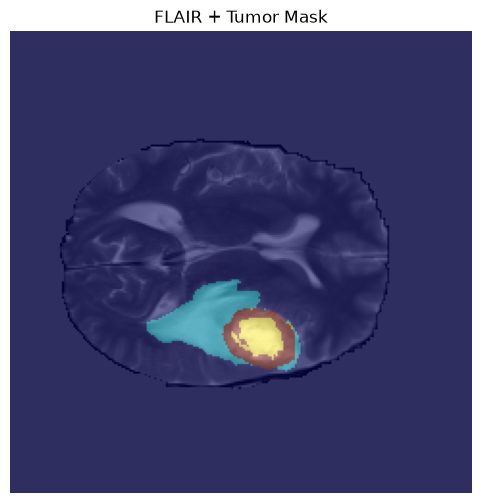

In [37]:
plt.figure(figsize=(6,6))

plt.imshow(
    slice_img,
    cmap="gray"
)

plt.imshow(
    mask_slice,
    cmap="jet",
    alpha=0.4
)

plt.title("FLAIR + Tumor Mask")

plt.axis("off")

plt.show()

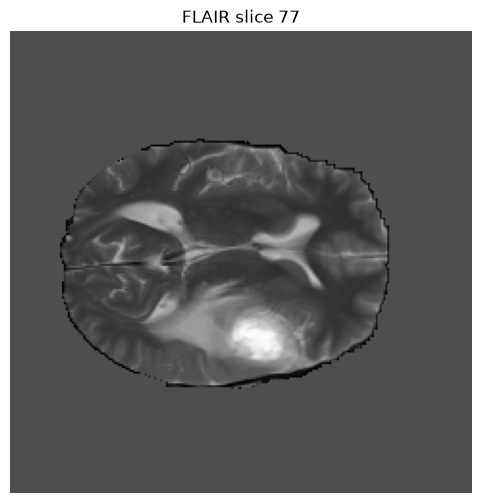

In [ ]:
#選擇MRI slice（３D>>2D）
flair = image[3]        #FLAIR影像
slice_idx = flair.shape[-1] // 2

slice_img = flair[:,:,slice_idx]

plt.figure(figsize=(6,6))

plt.imshow(
    slice_img,
    cmap="gray"
)

plt.axis("off")
plt.title(f"FLAIR slice {slice_idx}")

plt.show()

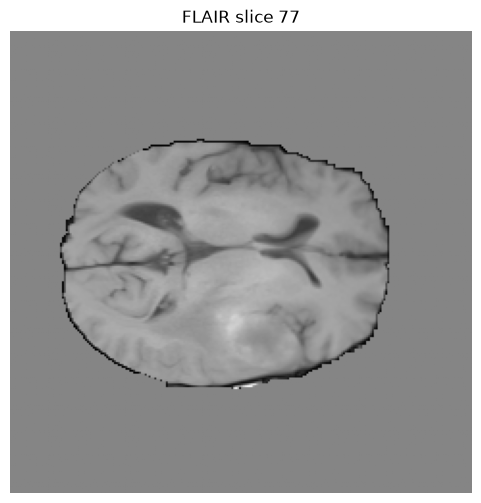

In [ ]:
#選擇MRI slice（３D>>2D）
flair = image[1]        #T1影像
slice_idx = flair.shape[-1] // 2

slice_img = flair[:,:,slice_idx]

plt.figure(figsize=(6,6))

plt.imshow(
    slice_img,
    cmap="gray"
)

plt.axis("off")
plt.title(f"FLAIR slice {slice_idx}")

plt.show()

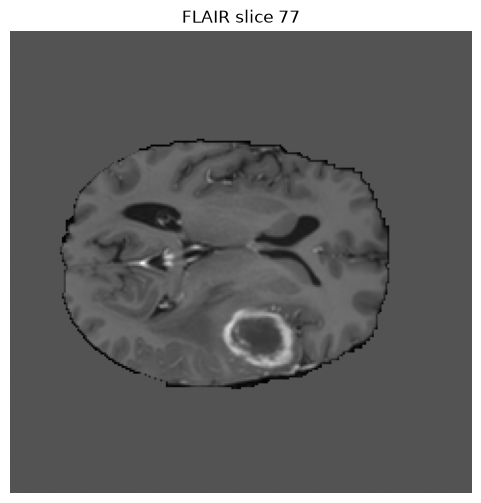

In [ ]:
#選擇MRI slice（３D>>2D）
flair = image[2]        #T2影像
slice_idx = flair.shape[-1] // 2

slice_img = flair[:,:,slice_idx]

plt.figure(figsize=(6,6))

plt.imshow(
    slice_img,
    cmap="gray"
)

plt.axis("off")
plt.title(f"FLAIR slice {slice_idx}")

plt.show()

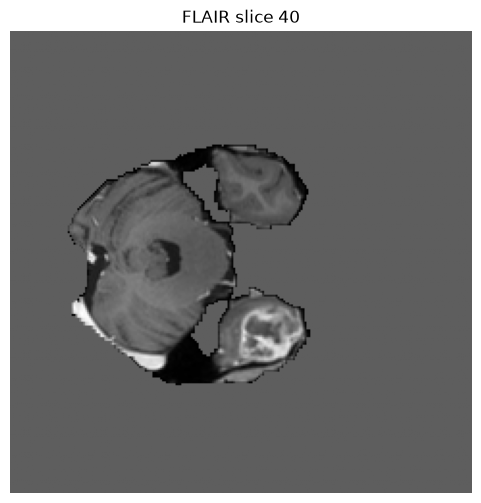

In [ ]:
#選擇MRI slice（３D>>2D）
flair = image[2]
slice_idx = 40      #第40層

slice_img = flair[:,:,slice_idx]

plt.figure(figsize=(6,6))

plt.imshow(
    slice_img,
    cmap="gray"
)

plt.axis("off")
plt.title(f"FLAIR slice {slice_idx}")

plt.show()

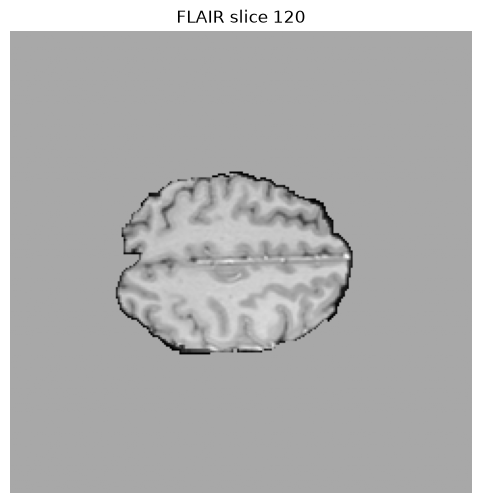

In [ ]:
flair = image[2]
slice_idx = 120     #第120層

slice_img = flair[:,:,slice_idx]

plt.figure(figsize=(6,6))

plt.imshow(
    slice_img,
    cmap="gray"
)

plt.axis("off")
plt.title(f"FLAIR slice {slice_idx}")

plt.show()

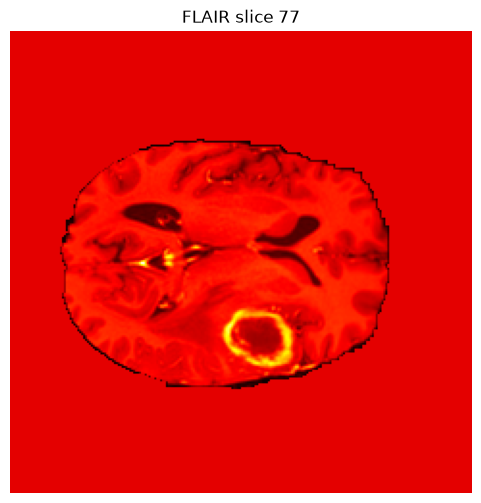

In [ ]:
flair = image[2]
slice_idx = 77

slice_img = flair[:,:,slice_idx]

plt.figure(figsize=(6,6))

plt.imshow(
    slice_img,
    cmap="hot"      #colormap: hot, gray, jet, etc.
)

plt.axis("off")
plt.title(f"FLAIR slice {slice_idx}")

plt.show()

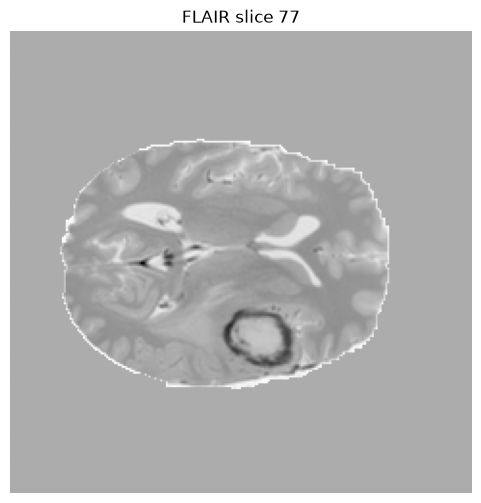

In [18]:
flair = image[2]
slice_idx = 77

slice_img = flair[:,:,slice_idx]

plt.figure(figsize=(6,6))

plt.imshow(
    slice_img,
    cmap="gray_r" 
)

plt.axis("off")
plt.title(f"FLAIR slice {slice_idx}")

plt.show()

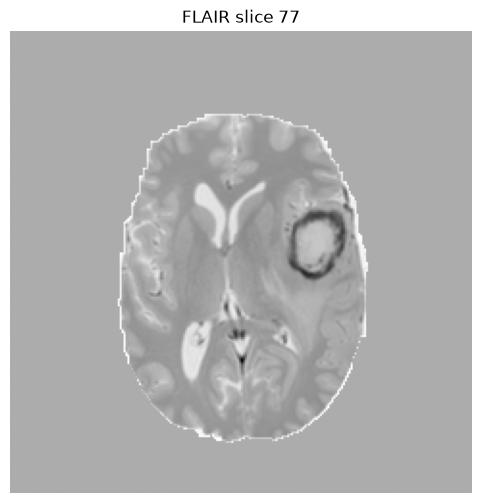

In [ ]:
flair = image[2]
slice_idx = 77

slice_img = flair[:,:,slice_idx]

rotated_img = np.rot90(slice_img)       #旋轉影像（轉90度）

plt.figure(figsize=(6,6))

plt.imshow(
    rotated_img,
    cmap="gray_r" 
)

plt.axis("off")
plt.title(f"FLAIR slice {slice_idx}")

plt.show()

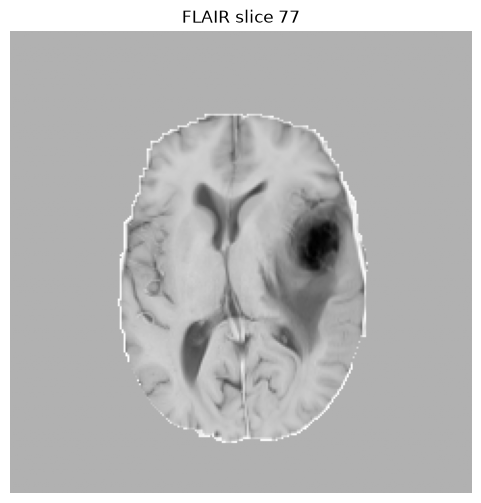

In [24]:
flair = image[3]
slice_idx = 77

slice_img = flair[:,:,slice_idx]

#旋轉影像（轉90度）
rotated_img = np.rot90(slice_img)

plt.figure(figsize=(6,6))

plt.imshow(
    rotated_img,
    cmap="gray_r" 
)

plt.axis("off")
plt.title(f"FLAIR slice {slice_idx}")

plt.show()

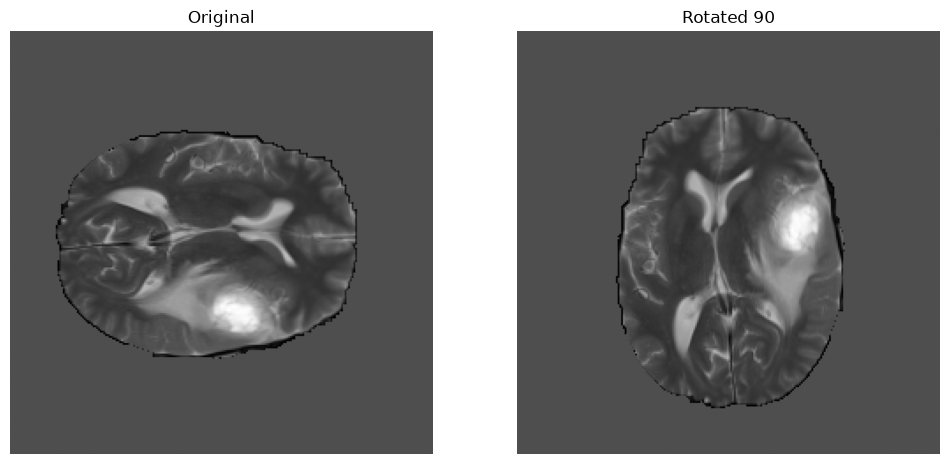

In [ ]:
flair = image[3]
slice_idx = 77

slice_img = flair[:,:,slice_idx]
rotated_img = np.rot90(slice_img)
#同時顯示原始影像及和旋轉的影像
plt.figure(figsize=(12,6))


plt.subplot(1,2,1)
plt.imshow(slice_img, cmap="gray")
plt.title("Original")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(rotated_img, cmap="gray")
plt.title("Rotated 90")
plt.axis("off")


plt.show()

Ｍask圖層
顯示 label 類別

In [26]:
label.shape

torch.Size([1, 240, 240, 155])

In [30]:
mask = label[0]
mask.shape
mask[:,:,77]
mask_slice = mask[:,:,slice_idx]

In [ ]:
np.unique(mask_slice)
#0 = background
#1 = necrotic / non-enhancing tumor
#2 = edema
#4 = enhancing tumor

array([0., 1., 2., 3.], dtype=float32)

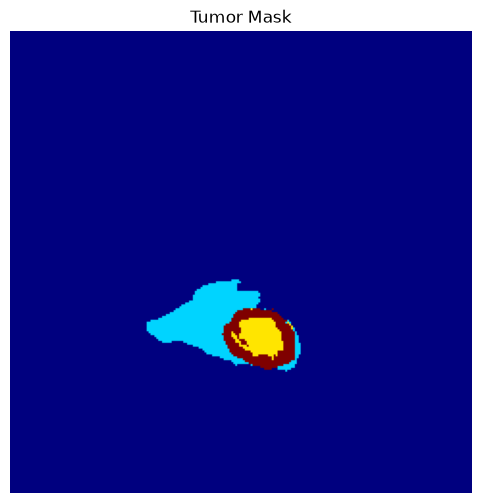

In [39]:
plt.figure(figsize=(6,6))

plt.imshow(
    mask_slice,
    cmap="jet"
)

plt.title("Tumor Mask")
plt.axis("off")

plt.show()

overlay疊圖

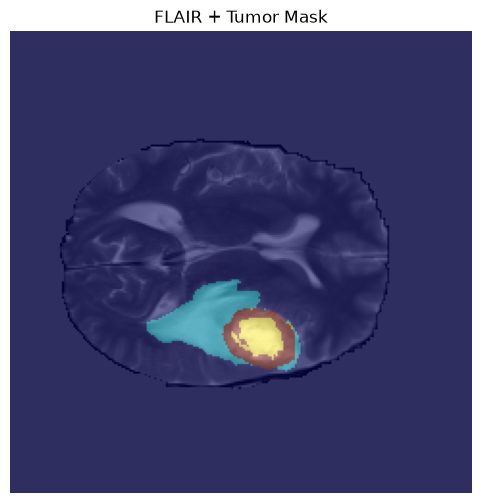

In [40]:
plt.figure(figsize=(6,6))


plt.imshow(
    slice_img,
    cmap="gray"
)


plt.imshow(
    mask_slice,
    cmap="jet",
    alpha=0.4              #控制透明度（0.2更透明mri清楚、0.8更明顯腫瘤突出）
)


plt.title("FLAIR + Tumor Mask")
plt.axis("off")


plt.show()

顯示原始 MRI、Mask、Overlay 三張

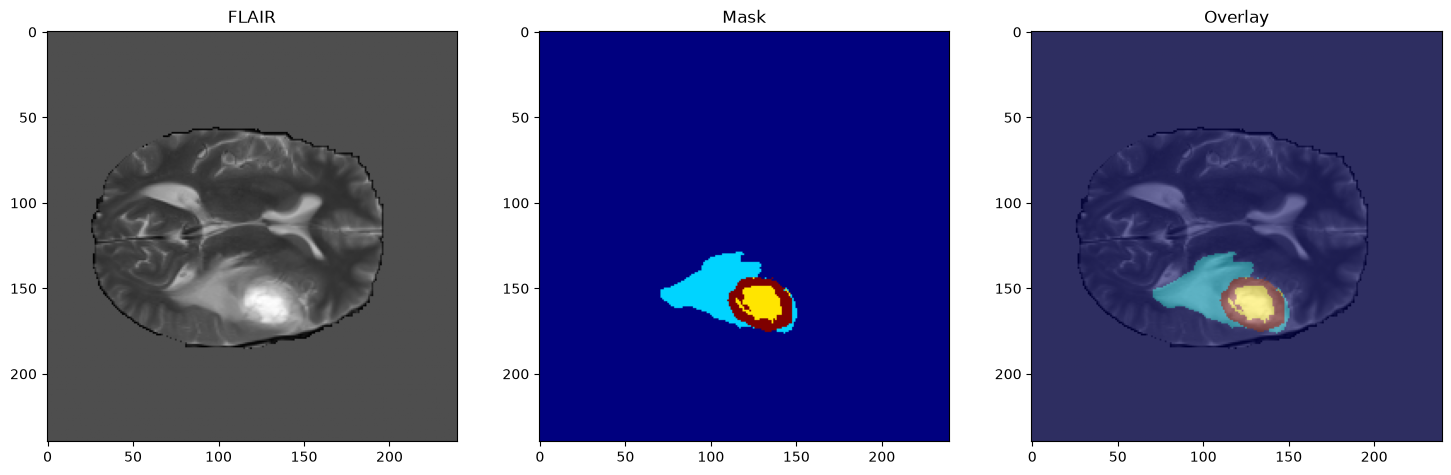

In [38]:
plt.figure(figsize=(18,6))


plt.subplot(1,3,1)
plt.imshow(slice_img,cmap="gray")
plt.title("FLAIR")


plt.subplot(1,3,2)
plt.imshow(mask_slice,cmap="jet")
plt.title("Mask")


plt.subplot(1,3,3)
plt.imshow(slice_img,cmap="gray")
plt.imshow(mask_slice,cmap="jet",alpha=0.4)
plt.title("Overlay")


plt.show()

Medical image quality assurance (QA)
確認：
Orientation 是否正確
Anatomical structure 是否合理
Label 是否與 anatomy 對齊

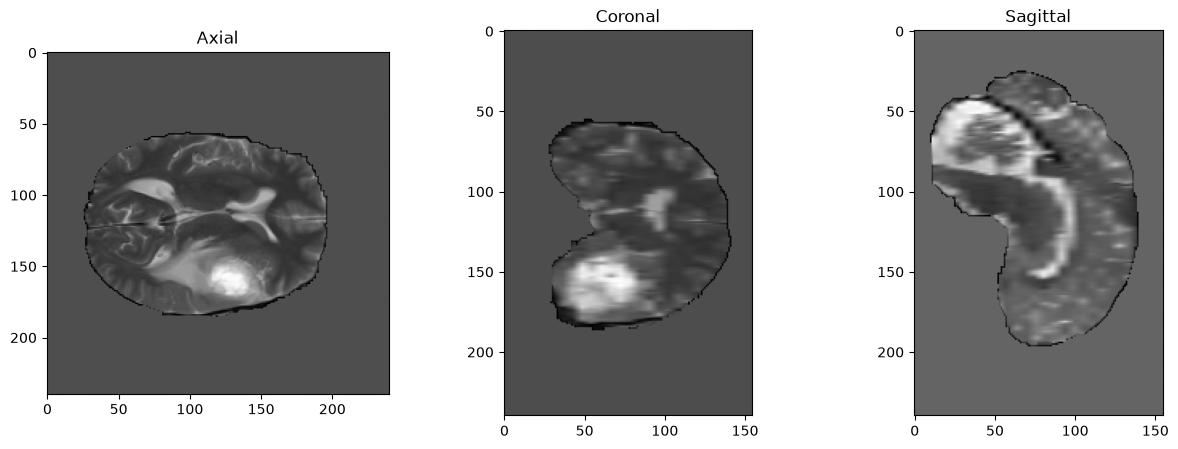

In [41]:
flair = image[3]
mask = label[0]

axial = flair[:,:,77]
coronal = flair[:,120,:]
sagittal = flair[120,:,:]

#一次顯示三個方向的影像
plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(axial,cmap="gray")
plt.title("Axial")


plt.subplot(1,3,2)
plt.imshow(coronal,cmap="gray")
plt.title("Coronal")


plt.subplot(1,3,3)
plt.imshow(sagittal,cmap="gray")
plt.title("Sagittal")


plt.show()

先建立三方向 mask slice

In [46]:
x_center = flair.shape[0] // 2
y_center = flair.shape[1] // 2
z_center = flair.shape[2] // 2
print(x_center)
print(y_center)
print(z_center)
flair.shape


120
120
77


torch.Size([240, 240, 155])

In [48]:
axial = flair[:,:,z_center]
coronal = flair[:,y_center,:]
sagittal = flair[x_center,:,:]

print(axial.shape)
print(coronal.shape)
print(sagittal.shape)

torch.Size([240, 240])
torch.Size([240, 155])
torch.Size([240, 155])


In [49]:
mask_axial = mask[:,:,z_center]
mask_coronal = mask[:,y_center,:]
mask_sagittal = mask[x_center,:,:]

print(mask_axial.shape)
print(mask_coronal.shape)
print(mask_sagittal.shape)

torch.Size([240, 240])
torch.Size([240, 155])
torch.Size([240, 155])


In [50]:
print(np.unique(mask_axial))
print(np.unique(mask_coronal))
print(np.unique(mask_sagittal))

[0. 1. 2. 3.]
[0. 1. 2. 3.]
[0.]


三個方向的overlay

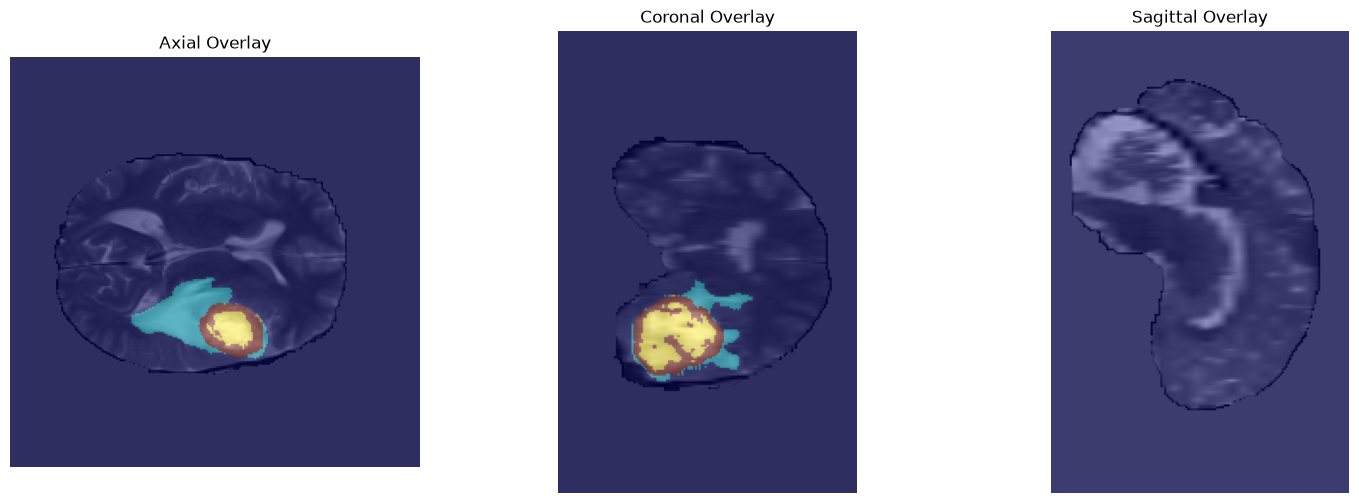

In [51]:
plt.figure(figsize=(18,6))


plt.subplot(1,3,1)

plt.imshow(
    axial,
    cmap="gray"
)

plt.imshow(
    mask_axial,
    cmap="jet",
    alpha=0.4
)

plt.title("Axial Overlay")
plt.axis("off")



plt.subplot(1,3,2)

plt.imshow(
    coronal,
    cmap="gray"
)

plt.imshow(
    mask_coronal,
    cmap="jet",
    alpha=0.4
)

plt.title("Coronal Overlay")
plt.axis("off")



plt.subplot(1,3,3)

plt.imshow(
    sagittal,
    cmap="gray"
)

plt.imshow(
    mask_sagittal,
    cmap="jet",
    alpha=0.4
)

plt.title("Sagittal Overlay")
plt.axis("off")


plt.show()